In [1]:
import gc
import os
import sys
import psutil
import pyarrow as pa
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
from joblib.externals.loky import get_reusable_executor
from multiprocessing import shared_memory
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "..")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() - 1 or 1
_TOTAL_MEMORY = psutil.virtual_memory().total
_AVAILABLE_MEMORY = psutil.virtual_memory().available
_MEMORY_PER_WORKER = max(100 * 1024**2, _AVAILABLE_MEMORY // (_NCPU + 1))
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | {_TOTAL_MEMORY / 1024**3:.1f}GB total RAM ({_AVAILABLE_MEMORY / 1024**3:.1f}GB available) | pyarrow {pa.__version__}", flush=True)

Running with 47 CPU cores | 92.3GB total RAM (88.3GB available) | pyarrow 24.0.0


Variables

In [2]:
%run ../0_Config/0_variables.ipynb

Feature ranking

In [3]:
import time as _time
_t0 = _time.perf_counter()
print(f"Loading features parquet: {os.environ['FEATURES_PATH']}", flush=True)
features = pd.read_parquet(os.environ["FEATURES_PATH"], filters=[
    ('SETTLEMENTDATE', '>=', pd.Timestamp(os.environ["FEATURE_DATASET_START"])),
    ('SETTLEMENTDATE', '<=', pd.Timestamp(os.environ["FEATIRE_DATASET_END"])),
])
features = features.drop(columns=[c for c in features.columns if c in set(os.environ["TARGET_COLS"].split(","))])
features = features.loc[:pd.Timestamp(os.environ["FEATIRE_DATASET_END"])]
print(f"  loaded features: shape={features.shape} in {_time.perf_counter() - _t0:.1f}s", flush=True)

_stem = Path(os.environ['FEATURE_DATASET']).stem
_t0 = _time.perf_counter()
print(f"Loading aggregated targets parquet for target={os.environ['TARGET']}, dataset={_stem}", flush=True)
future_prediction_targets_agg = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{os.environ['TARGET']}_targets_agg_{_stem}.parquet")
)
print(f"  loaded targets: shape={future_prediction_targets_agg.shape} in {_time.perf_counter() - _t0:.1f}s", flush=True)

"""
Rank features

MI ranking: measures mutual information — a non-linear, information-theoretic score. It answers "does knowing this feature reduce uncertainty about the target?",
capturing non-linear dependencies too. Targets are passed in pre-aggregated to output_resolution_minutes,
so MI is computed directly at the output resolution.
"""

# Worker-side cache: each loky worker reuses its SharedMemory attachment + ndarray view
# across the many tasks it processes (avoids re-attaching/re-wrapping per task).
_WORKER_SHM_CACHE = {}

def _attach_shared(name, shape, dtype):
    cached = _WORKER_SHM_CACHE.get(name)
    if cached is not None:
        return cached[1]
    shm = shared_memory.SharedMemory(name=name)
    arr = np.ndarray(shape, dtype=dtype, buffer=shm.buf)
    _WORKER_SHM_CACHE[name] = (shm, arr)  # keep shm alive for the worker's lifetime
    return arr

def rank_features(features:pd.DataFrame,
    future_prediction_targets_agg: pd.DataFrame,
    feature_selection_subsample_start: pd.Timestamp,
    feature_selection_subsample_end: pd.Timestamp,
    feature_selection_subsample_amount: int,
    output_resolution_minutes: int,
):
    feature_cols = list(features.columns)
    target_cols_agg = list(future_prediction_targets_agg.columns)
    n_buckets = len(target_cols_agg)

    def _filter_data_for_feature_time_range_subset():
        print(f"  filtering to subsample window [{feature_selection_subsample_start} .. {feature_selection_subsample_end}]", flush=True)
        features_subset = features.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        targets_subset = future_prediction_targets_agg.loc[feature_selection_subsample_start:feature_selection_subsample_end]
        shared_index = features_subset.index.intersection(targets_subset.index)
        print(f"    window rows: features={len(features_subset):,} targets={len(targets_subset):,} shared={len(shared_index):,}", flush=True)
        return features_subset.loc[shared_index], targets_subset.loc[shared_index]

    features_subset, targets_subset = _filter_data_for_feature_time_range_subset()

    # Detect discrete-looking columns BEFORE the float cast, so dtype info is preserved.
    # Integer dtypes are treated as discrete; small-cardinality float columns (<=32 uniques,
    # all integral values) are also flagged. Discrete-feature MI uses a much faster code path
    # in sklearn (no per-feature kNN noise injection / joint-space search).
    print(f"  detecting discrete features", flush=True)
    _t = _time.perf_counter()
    _discrete_mask = np.zeros(features_subset.shape[1], dtype=bool)
    for _i, _col in enumerate(feature_cols):
        _s = features_subset[_col]
        if _s.dtype.kind in ("i", "u", "b"):
            _discrete_mask[_i] = True
            continue
        if _s.dtype.kind == "f":
            _vals = _s.to_numpy()
            # cheap check: small unique count AND all integral
            if _vals.size and np.all(np.isfinite(_vals)):
                if np.unique(_vals).size <= 32 and np.all(_vals == np.floor(_vals)):
                    _discrete_mask[_i] = True
    print(
        f"    discrete features: {_discrete_mask.sum()} / {len(feature_cols)} "
        f"in {_time.perf_counter() - _t:.1f}s",
        flush=True,
    )

    # Avoid an unnecessary float32 copy when the underlying block is already float32 contiguous.
    print(f"  preparing feature ndarray (shape={features_subset.shape})", flush=True)
    _t = _time.perf_counter()
    _arr = features_subset.to_numpy(dtype=np.float32, copy=False)
    if not _arr.flags["C_CONTIGUOUS"]:
        _arr = np.ascontiguousarray(_arr)
    features_subset = _arr
    targets_subset = targets_subset.reset_index(drop=True)
    print(
        f"    ready in {_time.perf_counter() - _t:.1f}s | feature matrix "
        f"{features_subset.nbytes / 1024**2:.0f}MB | contiguous={features_subset.flags['C_CONTIGUOUS']}",
        flush=True,
    )

    def _subsample_features():
        seed = np.random.default_rng(42)
        n_samples = min(feature_selection_subsample_amount, len(features_subset))
        print(f"  subsampling {n_samples:,} of {len(features_subset):,} rows", flush=True)
        subsample_index = seed.choice(len(features_subset), size=n_samples, replace=False)
        subsample_index.sort()
        return features_subset[subsample_index], targets_subset.iloc[subsample_index]

    X_subsample, y_subsample = _subsample_features()

    def _mutual_information_scoring():
        aggregated_target_matrix = y_subsample[target_cols_agg].values.astype(np.float32)
        n_features = X_subsample.shape[1]
        n_subsample_rows = X_subsample.shape[0]

        # Chunk features so total tasks = n_buckets * n_chunks >> _NCPU. This saturates
        # all cores even when n_buckets < _NCPU and lets the scheduler load-balance
        # cheap discrete columns against expensive continuous ones.
        _target_tasks = max(_NCPU * 64, n_buckets * 64)
        _n_chunks = max(1, min(n_features, _target_tasks // max(1, n_buckets)))
        _chunk_size = max(1, (n_features + _n_chunks - 1) // _n_chunks)
        _chunks = [
            (start, min(start + _chunk_size, n_features))
            for start in range(0, n_features, _chunk_size)
        ]
        _n_tasks = len(_chunks) * n_buckets

        print(
            f"  MI scoring: {n_features} features × {n_buckets} horizons ({output_resolution_minutes}-min) "
            f"| subsample n={n_subsample_rows:,} | {_n_tasks} tasks ({len(_chunks)} feature chunks × {n_buckets} buckets) "
            f"across {_NCPU} CPUs | ~{_MEMORY_PER_WORKER / 1024**2:.0f}MB per worker",
            flush=True,
        )

        shm_X = None
        shm_y = None
        try:
            # Place arrays in shared memory so workers receive only a name string, not a pickled copy
            print(f"  allocating shared memory: X={X_subsample.nbytes / 1024**2:.0f}MB, y={aggregated_target_matrix.nbytes / 1024**2:.0f}MB", flush=True)
            _t = _time.perf_counter()
            shm_X = shared_memory.SharedMemory(create=True, size=X_subsample.nbytes)
            shm_y = shared_memory.SharedMemory(create=True, size=aggregated_target_matrix.nbytes)
            np.copyto(np.ndarray(X_subsample.shape, dtype=np.float32, buffer=shm_X.buf), X_subsample)
            np.copyto(np.ndarray(aggregated_target_matrix.shape, dtype=np.float32, buffer=shm_y.buf), aggregated_target_matrix)
            X_shape, y_shape = X_subsample.shape, aggregated_target_matrix.shape
            shm_X_name, shm_y_name = shm_X.name, shm_y.name
            print(f"    shared memory ready in {_time.perf_counter() - _t:.1f}s", flush=True)

            def _score_chunk(bucket_idx, col_start, col_end, chunk_discrete_mask):
                # Reuse worker-cached attachments across tasks (see _attach_shared).
                X = _attach_shared(shm_X_name, X_shape, np.float32)
                y = _attach_shared(shm_y_name, y_shape, np.float32)
                X_chunk = X[:, col_start:col_end]
                # Pass discrete_features as a boolean mask so sklearn uses the fast
                # discrete branch where applicable.
                result = mutual_info_regression(
                    X_chunk,
                    y[:, bucket_idx],
                    discrete_features=chunk_discrete_mask,
                    n_neighbors=3,
                    random_state=42,
                )
                return bucket_idx, col_start, col_end, result

            # Memory-capped worker count: each loky worker holds sklearn imports +
            # mmap of shared X/y + per-call NN structures. Empirically ~1.5GB resident
            # at 300k subsample. Cap n_jobs so total worker peak stays under 60% of
            # currently-available RAM. Prevents OOM kernel kills.
            _avail = psutil.virtual_memory().available
            _per_worker_bytes = max(1_500 * 1024**2, int(X_shape[0] * 5_000))
            _mem_cap = max(1, int(0.6 * _avail / _per_worker_bytes))
            _n_jobs = max(1, min(_NCPU, _mem_cap))
            print(
                f"  worker cap: NCPU={_NCPU}, mem-budget allows {_mem_cap} workers "
                f"(per-worker ~{_per_worker_bytes / 1024**2:.0f}MB, available {_avail / 1024**3:.1f}GB) "
                f"-> using n_jobs={_n_jobs}",
                flush=True,
            )
            print(
                f"  spawning {_n_jobs} loky workers and dispatching {_n_tasks} tasks "
                f"(first results may take ~30s while workers warm up)",
                flush=True,
            )
            # Warm up workers: dispatch trivial no-ops so the loky pool spawns,
            # forks, imports sklearn, and attaches shared memory BEFORE the real
            # workload starts. Without this you stare at a 0/N bar for ~60s.
            # Dispatch 2x n_jobs so every worker is guaranteed to receive at least one.
            def _warmup(_):
                from sklearn.feature_selection import mutual_info_regression as _mir
                import numpy as _np
                _attach_shared(shm_X_name, X_shape, np.float32)
                _attach_shared(shm_y_name, y_shape, np.float32)
                # pre-warm sklearn kNN so first real task doesn't cold-start
                _xw = _np.random.rand(200, 3).astype(_np.float32)
                _yw = _np.random.rand(200).astype(_np.float32)
                _mir(_xw, _yw, n_neighbors=3, random_state=42)
                return os.getpid()
            print(f"  warming up {_n_jobs} workers (forking + sklearn import + SHM attach)...", flush=True)
            _t_warm = _time.perf_counter()
            _warm_n = _n_jobs * 2
            _warm_gen = Parallel(n_jobs=_n_jobs, backend="loky", batch_size=1, return_as="generator_unordered")(
                delayed(_warmup)(i) for i in range(_warm_n)
            )
            _warm_pids = set()
            for _pid in tqdm(_warm_gen, total=_warm_n, desc="worker warmup", unit="worker", smoothing=0.05, mininterval=0.2, dynamic_ncols=True, leave=True):
                _warm_pids.add(_pid)
            print(f"    warmup done in {_time.perf_counter() - _t_warm:.1f}s ({len(_warm_pids)} unique worker PIDs)", flush=True)
            try:
                _t_dispatch = _time.perf_counter()
                gen = Parallel(n_jobs=_n_jobs, backend="loky", batch_size=1, return_as="generator_unordered")(
                    delayed(_score_chunk)(bucket_idx, cs, ce, _discrete_mask[cs:ce])
                    for bucket_idx in range(n_buckets)
                    for (cs, ce) in _chunks
                )
                scores = np.empty((n_features, n_buckets))
                _first = True
                _bar = tqdm(
                    gen, total=_n_tasks, desc="MI scoring",
                    unit="task", smoothing=0.05, mininterval=0.5,
                    dynamic_ncols=True, leave=True,
                )
                _buckets_done = [False] * n_buckets
                _bucket_chunks_left = {b: len(_chunks) for b in range(n_buckets)}
                _last_bucket = None
                for bucket_idx, cs, ce, chunk_scores in _bar:
                    if _first:
                        print(f"    first worker result received after {_time.perf_counter() - _t_dispatch:.1f}s", flush=True)
                        _first = False
                    scores[cs:ce, bucket_idx] = chunk_scores
                    _bucket_chunks_left[bucket_idx] -= 1
                    if _bucket_chunks_left[bucket_idx] == 0:
                        _buckets_done[bucket_idx] = True
                        _last_bucket = bucket_idx
                    _n_done = sum(_buckets_done)
                    _bar.set_postfix(
                        buckets=f"{_n_done}/{n_buckets}",
                        last_h=(f"h{_last_bucket+1}" if _last_bucket is not None else "-"),
                        refresh=False,
                    )
            finally:
                # Force-shutdown loky pool so workers cannot orphan if the
                # kernel later crashes / is restarted mid-cell. Without this,
                # repeated runs leak workers each holding ~1.5GB resident.
                try:
                    get_reusable_executor().shutdown(wait=True, kill_workers=True)
                except Exception:
                    pass
        finally:
            if shm_X is not None:
                shm_X.close(); shm_X.unlink()
            if shm_y is not None:
                shm_y.close(); shm_y.unlink()

        mi_matrix = pd.DataFrame(scores, index=feature_cols, columns=target_cols_agg)
        feature_cols_ranked = mi_matrix.mean(axis=1).sort_values(ascending=False)
        return feature_cols_ranked, mi_matrix

    feature_cols_ranked, mi_matrix = _mutual_information_scoring()

    df = pd.DataFrame({
        "rank": range(1, len(feature_cols_ranked) + 1),
        "feature": feature_cols_ranked.index,
        "mean_mi": feature_cols_ranked.values,
        "target": os.environ["TARGET"],
        "feature_dataset": Path(os.environ["FEATURE_DATASET"]).stem,
    }).set_index("feature")

    df_horizons = mi_matrix.reindex(feature_cols_ranked.index)
    feature_data = pd.concat([df, df_horizons], axis=1).reset_index(names="feature")

    display(feature_data[:3])
    return feature_data

feature_data = rank_features(
    features=features,
    future_prediction_targets_agg=future_prediction_targets_agg,
    feature_selection_subsample_start=pd.Timestamp(os.environ["FEATURE_SELECTION_SUBSAMPLE_START"]),
    feature_selection_subsample_end=pd.Timestamp(os.environ["FEATURE_SELECTION_SUBSAMPLE_END"]),
    feature_selection_subsample_amount=int(os.environ["FEATURE_RANKING_SUBSAMPLE_AMOUNT"]),
    output_resolution_minutes=int(os.environ["OUTPUT_RESOLUTION"]),
)

_stem = Path(os.environ['FEATURE_DATASET']).stem
feature_data.to_parquet(
    resolve(f"3_Features_select/Selected_features/{os.environ['TARGET']}_feature_data_{_stem}.parquet")
)


Loading features parquet: /home/ec2-user/Forecasting/3_Features_select/../2_Features_build/Feature_data/1_dispatch_price.parquet
  loaded features: shape=(736417, 634) in 11.6s
Loading aggregated targets parquet for target=NSW, dataset=1_dispatch_price
  loaded targets: shape=(736417, 96) in 2.2s
  filtering to subsample window [2019-01-01 00:00:00 .. 2024-01-01 00:00:00]
    window rows: features=525,889 targets=525,889 shared=525,889
  detecting discrete features
    discrete features: 92 / 634 in 1.7s
  preparing feature ndarray (shape=(525889, 634))
    ready in 1.2s | feature matrix 1272MB | contiguous=True
  subsampling 300,000 of 525,889 rows
  MI scoring: 634 features × 96 horizons (30-min) | subsample n=300,000 | 768 tasks (8 feature chunks × 96 buckets) across 47 CPUs | ~1885MB per worker
  allocating shared memory: X=726MB, y=110MB
    shared memory ready in 0.6s
  worker cap: NCPU=47, mem-budget allows 33 workers (per-worker ~1500MB, available 81.0GB) -> using n_jobs=33
  s

worker warmup: 100%|██████████| 66/66 [00:00<00:00, 171.02worker/s]

    warmup done in 0.8s (18 unique worker PIDs)



MI scoring:   0%|          | 0/768 [00:00<?, ?task/s]

    first worker result received after 152.3s


MI scoring: 100%|██████████| 768/768 [1:37:35<00:00,  7.62s/task, buckets=96/96, last_h=h96]


,feature,rank,mean_mi,target,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96
0,nsw_price_q90_336,1,0.837878,NSW,1_dispatch_price,0.950705,0.926782,0.912109,0.895848,0.883318,0.874949,0.861987,0.860274,0.851661,0.845989,0.839568,0.838834,0.838926,0.840020,0.847188,0.851285,0.850297,0.853766,0.848481,0.845089,0.846129,0.847760,0.839731,0.851217,0.845775,0.842526,0.846055,0.845617,0.835627,0.833919,0.834475,0.834990,0.833212,0.834770,0.837920,0.841120,0.854848,0.857009,0.859746,0.866942,0.868670,0.879866,0.890947,0.889223,0.895265,0.898173,0.884260,0.875929,0.863112,0.853694,0.839088,0.838118,0.823311,0.815871,0.808456,0.810787,0.801101,0.797696,0.794344,0.793258,0.799978,0.793709,0.803005,0.805723,0.805581,0.808263,0.806967,0.810570,0.801654,0.806925,0.808775,0.811499,0.802642,0.804334,0.800346,0.804587,0.801661,0.794225,0.798425,0.796425,0.797189,0.797124,0.794834,0.802387,0.806417,0.810305,0.822896,0.822621,0.830961,0.836018,0.847147,0.854348,0.861311,0.863496,0.851025,0.845321
1,qld_price_q90_336,2,0.820431,NSW,1_dispatch_price,0.901699,0.884745,0.875009,0.857989,0.851772,0.845726,0.839024,0.832097,0.827308,0.821402,0.810707,0.816850,0.813884,0.822161,0.826763,0.826343,0.826868,0.829329,0.826015,0.824453,0.825155,0.831233,0.827192,0.833182,0.828110,0.831360,0.832512,0.832551,0.828823,0.822935,0.820638,0.821115,0.819743,0.821382,0.819371,0.821434,0.827416,0.832785,0.840072,0.843878,0.844776,0.859293,0.869472,0.873901,0.879550,0.877780,0.865643,0.858122,0.844157,0.837032,0.822227,0.816472,0.805683,0.795935,0.793103,0.790933,0.785380,0.784102,0.777009,0.777828,0.784508,0.786506,0.789425,0.789775,0.788051,0.787632,0.787941,0.791300,0.787573,0.791019,0.791947,0.793861,0.793090,0.800278,0.791584,0.799503,0.797811,0.792300,0.789579,0.786681,0.787711,0.789172,0.791260,0.791146,0.793849,0.800746,0.804438,0.815400,0.820346,0.825107,0.837420,0.841363,0.850579,0.847373,0.836903,0.828730
2,nsw_price_q10_336,3,0.802289,NSW,1_dispatch_price,0.918259,0.897682,0.885073,0.866261,0.857136,0.848548,0.847000,0.840725,0.838757,0.836334,0.822819,0.828960,0.820621,0.817962,0.806804,0.808986,0.803749,0.805756,0.795695,0.791901,0.792996,0.792847,0.786388,0.790973,0.789123,0.793778,0.798192,0.799823,0.793022,0.796399,0.799612,0.798895,0.798213,0.798059,0.802693,0.810554,0.814483,0.816369,0.820091,0.828386,0.832283,0.834218,0.841146,0.838008,0.840661,0.838733,0.832593,0.824404,0.821145,0.816867,0.804505,0.800587,0.793280,0.792408,0.797394,0.795037,0.795488,0.791653,0.786046,0.784550,0.785650,0.778047,0.780461,0.780048,0.769239,0.765825,0.764848,0.764213,0.756509,0.760835,0.760359,0.757578,0.759399,0.763964,0.764718,0.770970,0.773568,0.767007,0.769258,0.769427,0.770256,0.769264,0.770898,0.771646,0.777948,0.778397,0.779903,0.788851,0.791366,0.794429,0.805208,0.807102,0.814386,0.808204,0.807012,0.801975


Running with 47 CPU cores | 92.3GB total RAM (85.1GB available) | pyarrow 24.0.0
Loading [ranked] /home/ec2-user/Forecasting/3_Features_select/../3_Features_select/Selected_features/NSW_feature_data_1_dispatch_price.parquet
  loaded ranked: shape=(634, 96) in 0.0s


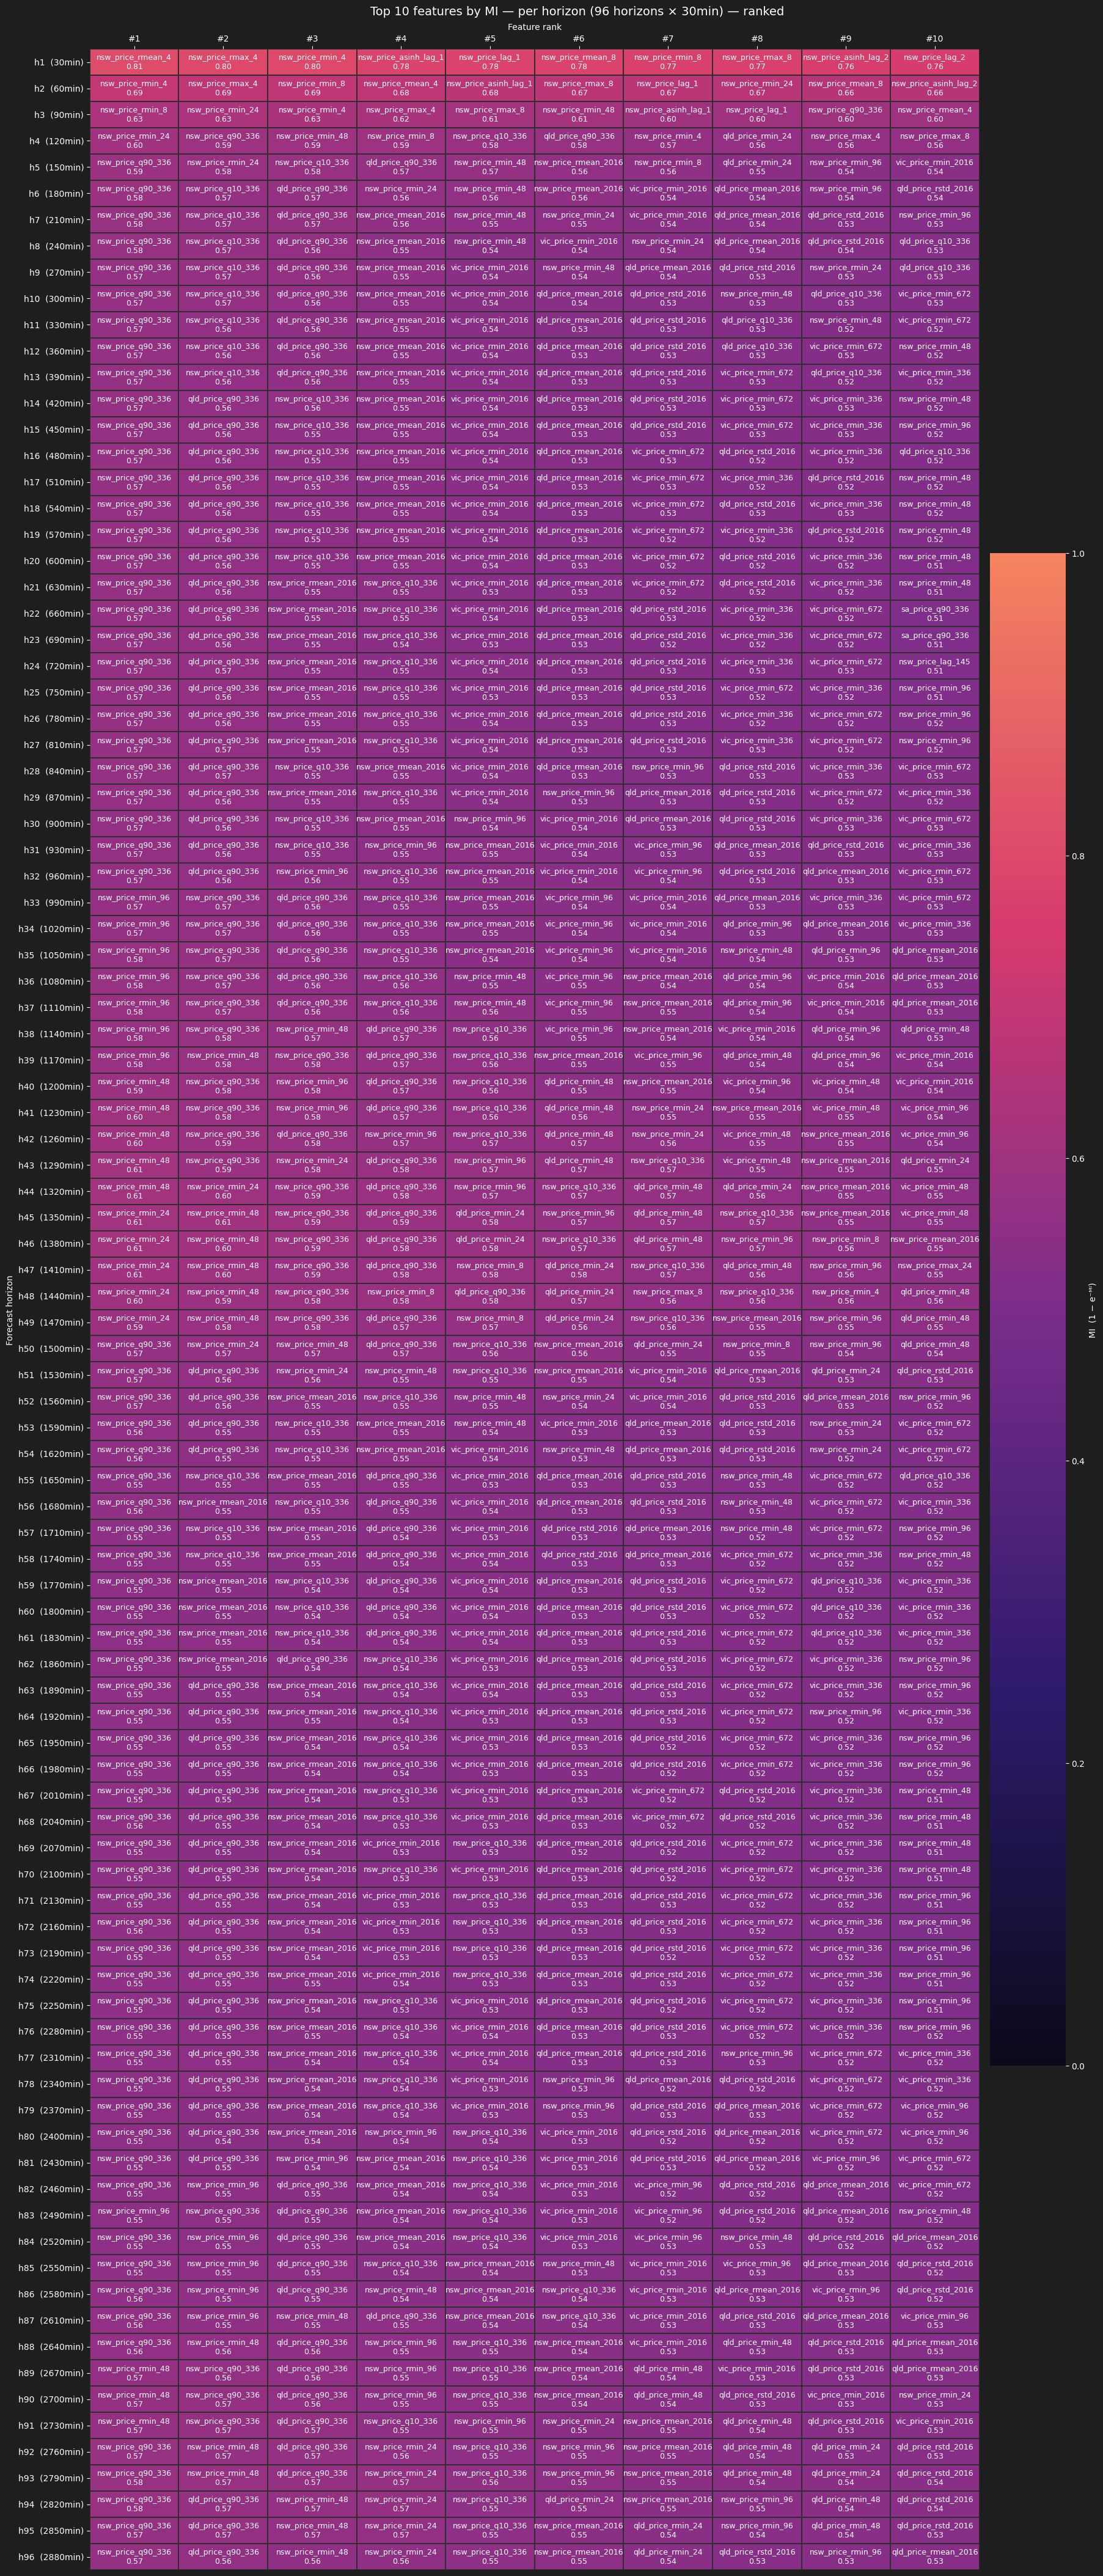

In [4]:
# Correlation matrix helper (auto-detects source if omitted)
%run 0_correlation_matrix.ipynb
plot_mi_top_features(source="ranked", top_n=10)


In [ ]:
%reset -f